# Student Performance Grade Prediction

This notebook builds a simple machine learning model to predict a student's final grade from academic, attendance, study, and background information.

**Model:** Random Forest Classifier  
**Target:** `grade`

The notebook is intentionally kept simple and practical:
- Load the dataset
- Perform basic EDA
- Prepare the input features
- Train one model
- Evaluate the model
- Show sample predictions
- Save predictions to a CSV file


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Dataset

In [ ]:
# Find the correct student performance CSV
# The loader checks the column names instead of simply taking the first CSV file.

search_paths = [os.getcwd(), "/"]
csv_files = []

for base_path in search_paths:
    if os.path.exists(base_path):
        csv_files.extend(
            glob.glob(os.path.join(base_path, "**", "*.csv"), recursive=True)
        )

csv_files = list(dict.fromkeys(csv_files))

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found. Add the Student Performance Grade Prediction dataset to Kaggle."
    )

def normalize_columns(columns):
    """Make column names consistent, e.g. 'Grade' -> 'grade'."""
    return [
        str(col).strip().lower().replace(" ", "_").replace("-", "_")
        for col in columns
    ]

# Look for the CSV that contains the target column.
target_candidates = {"grade", "final_grade", "student_grade", "grade_category"}

data_path = None
raw_preview = None

for file in csv_files:
    try:
        preview = pd.read_csv(file, nrows=5)
        normalized = set(normalize_columns(preview.columns))
        if normalized.intersection(target_candidates):
            data_path = file
            raw_preview = preview
            break
    except Exception:
        continue

if data_path is None:
    raise ValueError(
        "The correct Student Performance dataset was not found. "
        "No CSV containing a grade/grade target column was detected.\n\n"
        f"CSV files checked: {csv_files}"
    )

df = pd.read_csv(data_path)

# Normalize column names once so the rest of the notebook is consistent.
df.columns = normalize_columns(df.columns)

# Detect the target column.
target_matches = [col for col in df.columns if col in target_candidates]

if not target_matches:
    raise ValueError(
        "A grade target column was not found after loading the dataset.\n"
        f"Available columns: {list(df.columns)}"
    )

target = target_matches[0]

print("Dataset loaded successfully.")
print("Dataset path:", data_path)
print("Dataset shape:", df.shape)
print("Target column:", target)
print("\nColumns:")
print(list(df.columns))

df.head()

Dataset loaded successfully.
Dataset path: /kaggle/input/datasets/dakshbhalala/student-performance-grade-prediction/student_performance.csv
Dataset shape: (50000, 18)
Target column: grade

Columns:
['student_id', 'age', 'gender', 'study_hours_per_day', 'attendance_percentage', 'sleep_hours_per_day', 'assignment_score', 'quiz_score', 'midterm_score', 'previous_gpa', 'previous_backlogs', 'internet_access', 'extracurricular_hours', 'parent_education', 'final_exam_score', 'overall_percentage', 'grade', 'pass_fail']


,student_id,age,gender,study_hours_per_day,attendance_percentage,sleep_hours_per_day,assignment_score,quiz_score,midterm_score,previous_gpa,previous_backlogs,internet_access,extracurricular_hours,parent_education,final_exam_score,overall_percentage,grade,pass_fail
0,STU00001,21,Female,5.0,100.0,6.9,85.5,69.1,76.4,8.17,0,Yes,2.8,High School,70.7,74.18,B+,Pass
1,STU00002,21,Male,1.6,66.5,8.7,28.8,51.9,28.3,4.49,3,Yes,2.2,Doctorate,40.7,36.94,F,Fail
2,STU00003,20,Female,2.7,84.1,6.9,72.3,65.2,82.8,7.84,0,Yes,3.4,Bachelor's,57.8,66.96,B,Pass
3,STU00004,21,Female,2.3,67.1,7.9,74.5,72.3,67.7,8.00,0,Yes,2.2,High School,50.0,60.33,B,Pass
4,STU00005,18,Female,3.4,90.5,6.6,70.9,67.9,59.1,6.35,0,Yes,13.9,Master's,50.6,57.50,C,Pass


## 2. Basic EDA

In [ ]:
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print(f"\nGrade distribution ({target}):")
print(df[target].value_counts())

print("\nNumerical summary:")
df.describe(include="all").T.head(20)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             50000 non-null  object 
 1   age                    50000 non-null  int64  
 2   gender                 50000 non-null  object 
 3   study_hours_per_day    49233 non-null  float64
 4   attendance_percentage  49451 non-null  float64
 5   sleep_hours_per_day    49071 non-null  float64
 6   assignment_score       50000 non-null  float64
 7   quiz_score             50000 non-null  float64
 8   midterm_score          50000 non-null  float64
 9   previous_gpa           49308 non-null  float64
 10  previous_backlogs      50000 non-null  int64  
 11  internet_access        49364 non-null  object 
 12  extracurricular_hours  49066 non-null  float64
 13  parent_education       48847 non-null  object 
 14  final_exam_score       50000 non-

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,50000,50000,STU49984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,50000.0,NaN,NaN,NaN,19.93494,1.550444,17.0,19.0,20.0,21.0,25.0
gender,50000,3,Male,25311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,49233.0,NaN,NaN,NaN,3.008714,1.374274,0.5,2.0,2.8,3.8,10.0
attendance_percentage,49451.0,NaN,NaN,NaN,79.936145,9.491763,50.0,73.5,80.0,86.5,100.0
sleep_hours_per_day,49071.0,NaN,NaN,NaN,7.395264,1.03775,4.0,6.7,7.4,8.1,10.0
assignment_score,50000.0,NaN,NaN,NaN,67.480912,13.660742,11.0,58.3,67.7,77.0,100.0
quiz_score,50000.0,NaN,NaN,NaN,61.732832,14.067162,2.6,52.3,62.1,71.5,100.0
midterm_score,50000.0,NaN,NaN,NaN,64.594698,16.136316,0.0,53.9,65.2,76.0,100.0
previous_gpa,49308.0,NaN,NaN,NaN,6.915433,1.684711,2.0,5.76,6.95,8.13,9.95


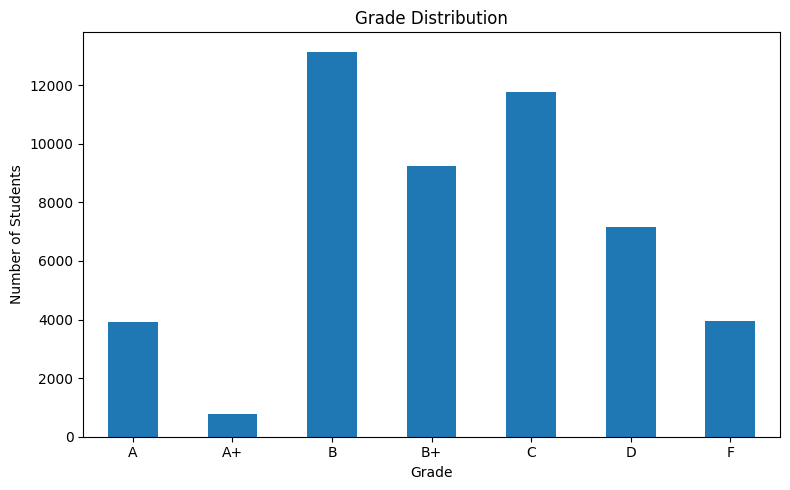

In [ ]:
# Grade distribution
plt.figure(figsize=(8, 5))
df[target].value_counts().sort_index().plot(kind="bar")
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

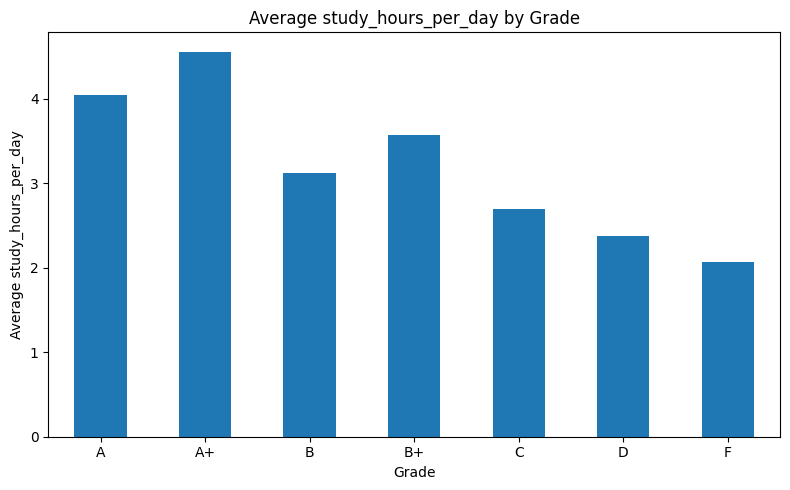

In [ ]:
# Basic relationship between study hours and grade
# This chart is shown only if the dataset contains a study-hours column.

study_candidates = [
    "study_hours_per_day",
    "study_hours",
    "daily_study_hours",
    "study_hours_per_week"
]

study_column = next(
    (col for col in study_candidates if col in df.columns),
    None
)

if study_column is not None:
    grade_means = df.groupby(target)[study_column].mean().sort_index()

    plt.figure(figsize=(8, 5))
    grade_means.plot(kind="bar")
    plt.title(f"Average {study_column} by Grade")
    plt.xlabel("Grade")
    plt.ylabel(f"Average {study_column}")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Study-hours column not found. Skipping this optional chart.")

## 3. Prepare Input Features

In [ ]:
# Prepare input features

# Columns that should not be used as model inputs when present:
# - ID columns
# - final result columns that directly reveal the target
possible_excluded = [
    "student_id",
    "id",
    "final_exam_score",
    "overall_percentage",
    "pass_fail",
    "final_grade",
    "student_grade"
]

excluded_columns = [
    col for col in possible_excluded
    if col in df.columns and col != target
]

feature_columns = [
    col for col in df.columns
    if col != target and col not in excluded_columns
]

if not feature_columns:
    raise ValueError("No input features are available after removing the target and excluded columns.")

X = df[feature_columns].copy()
y = df[target].copy()

# Fill missing values
numeric_columns = X.select_dtypes(include=["number"]).columns
categorical_columns = X.select_dtypes(exclude=["number"]).columns

for col in numeric_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    mode = X[col].mode()
    X[col] = X[col].fillna(mode.iloc[0] if not mode.empty else "Missing")

# Convert categorical columns into numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

print("Excluded columns:", excluded_columns)
print("Original input columns:", len(feature_columns))
print("Final model features after encoding:", X.shape[1])
print("\nFeatures used:")
print(feature_columns)
print("\nFinal feature matrix shape:", X.shape)

Excluded columns: ['student_id', 'final_exam_score', 'overall_percentage', 'pass_fail']
Original input columns: 13
Final model features after encoding: 17

Features used:
['age', 'gender', 'study_hours_per_day', 'attendance_percentage', 'sleep_hours_per_day', 'assignment_score', 'quiz_score', 'midterm_score', 'previous_gpa', 'previous_backlogs', 'internet_access', 'extracurricular_hours', 'parent_education']

Final feature matrix shape: (50000, 17)


## 4. Split the Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 40000
Testing samples: 10000


## 5. Train the Model

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 6. Evaluate the Model

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy (%): {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.5977
Accuracy (%): 59.77%

Classification Report:
              precision    recall  f1-score   support

           A       0.61      0.57      0.59       785
          A+       0.65      0.36      0.46       154
           B       0.58      0.62      0.60      2630
          B+       0.59      0.58      0.59      1850
           C       0.57      0.61      0.59      2354
           D       0.59      0.55      0.57      1434
           F       0.78      0.67      0.72       793

    accuracy                           0.60     10000
   macro avg       0.63      0.57      0.59     10000
weighted avg       0.60      0.60      0.60     10000



## 7. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {c}" for c in model.classes_],
    columns=[f"Predicted {c}" for c in model.classes_]
)

cm_df

,Predicted A,Predicted A+,Predicted B,Predicted B+,Predicted C,Predicted D,Predicted F
Actual A,445,28,22,290,0,0,0
Actual A+,91,55,0,8,0,0,0
Actual B,6,1,1636,430,540,16,1
Actual B+,183,0,559,1080,27,1,0
Actual C,0,0,588,14,1445,297,10
Actual D,0,0,26,0,484,786,138
Actual F,0,0,2,0,19,242,530


## 8. Sample Predictions

In [ ]:
sample_output = pd.DataFrame({
    "Actual Grade": y_test.reset_index(drop=True),
    "Predicted Grade": pd.Series(y_pred)
})

sample_output.head(10)

,Actual Grade,Predicted Grade
0,B,B+
1,A,A
2,D,D
3,B+,B
4,C,B
5,C,C
6,B,B
7,C,C
8,C,C
9,D,C


## 9. Predict Grade for One Student

In [ ]:
# Take one real student from the test set and show input -> output

sample_index = X_test.index[0]

# Original student input used by the model
sample_input = df.loc[[sample_index], feature_columns].copy()

# Apply the same basic missing-value treatment as the training data
sample_processed = sample_input.copy()

for col in sample_processed.select_dtypes(include=["number"]).columns:
    sample_processed[col] = sample_processed[col].fillna(
        df[col].median()
    )

for col in sample_processed.select_dtypes(exclude=["number"]).columns:
    mode = df[col].mode()
    sample_processed[col] = sample_processed[col].fillna(
        mode.iloc[0] if not mode.empty else "Missing"
    )

# Convert categorical values to the same dummy-variable format
sample_processed = pd.get_dummies(sample_processed, drop_first=True)

# Match the exact feature columns used during training
sample_processed = sample_processed.reindex(columns=X.columns, fill_value=0)

# Predict the grade
predicted_grade = model.predict(sample_processed)[0]
actual_grade = df.loc[sample_index, target]

print("INPUT - Student Information")
display(sample_input.T.rename(columns={sample_index: "Value"}))

print("\nOUTPUT")
print("Actual Grade:   ", actual_grade)
print("Predicted Grade:", predicted_grade)

INPUT - Student Information


,Value
age,19
gender,Male
study_hours_per_day,2.8
attendance_percentage,86.0
sleep_hours_per_day,8.0
assignment_score,77.3
quiz_score,62.8
midterm_score,82.0
previous_gpa,7.39
previous_backlogs,0



OUTPUT
Actual Grade:    B
Predicted Grade: B+


## Conclusion

The notebook uses a Random Forest Classifier to predict student grades from the available student information.

The final section demonstrates one complete prediction by showing the student's input values and the grade predicted by the trained model.